# 중고차 가격 예측 회귀 모델 분석

본 노트북에서는 중고차 가격 예측을 위한 회귀 모델(Regression Model)을 구현한다.

특히 다음 두 가지 경우를 비교한다.

1. 기본 모델(Baseline Model)
   - 기존 차량 정보만 사용

2. 향상 모델(Enhanced Model)
   - 기존 차량 정보 + 추정 MSRP(feature) 사용

이를 통해 MSRP feature가 실제 중고차 가격 예측 성능 향상에 기여하는지 분석한다.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone

## Step 1. 데이터 불러오기

전처리 및 MSRP feature 생성이 완료된 데이터를 불러온다.

- target 변수: `price`
- MSRP feature: `estimate_msrp`

In [2]:
df = pd.read_csv("vehicles_msrp.csv")

print("데이터 크기:", df.shape)

df.head()

데이터 크기: (7192, 15)


,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,type,paint_color,vehicle_age,estimate_msrp
0,20999,nissan,frontier,good,6 cylinders,gas,72238.0,clean,automatic,1N6AD0EV1GN794000,4wd,truck,black,5.0,35290.0
1,8495,ford,fiestas,like new,4 cylinders,gas,59734.0,clean,automatic,3FADP4TJ6GM170546,fwd,hatchback,silver,5.0,14000.0
2,29590,ford,expeditionxltsport,good,6 cylinders,gas,70760.0,clean,other,1FMJU1JT1HEA52352,4wd,SUV,blue,4.0,51540.0
3,11400,audi,a4quattropremium,like new,4 cylinders,gas,80146.0,clean,automatic,WAUBFAFL0BN036420,4wd,sedan,grey,10.0,33500.0
4,12999,hyundai,veloster,excellent,4 cylinders,gas,78554.0,clean,automatic,KMHTC6AD2FU239829,fwd,coupe,red,6.0,19800.0


## Step 2. 데이터 샘플링

MSRP feature가 추가된 전체 데이터 중 일부를 샘플링하여 모델링에 사용한다.

전체 데이터에서 무작위로 5,000개를 추출하며, `random_state=42`를 설정하여 동일한 결과가 재현되도록 한다.

In [3]:
SAMPLE_SIZE = 5000

df = df.sample(
    n=SAMPLE_SIZE,
    random_state=42
).reset_index(drop=True)

print("샘플링 후 데이터 크기:", df.shape)

df.head()

샘플링 후 데이터 크기: (5000, 15)


,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,type,paint_color,vehicle_age,estimate_msrp
0,17995,audi,a4,good,4 cylinders,gas,65808.0,clean,automatic,WAUFFAFL4FN008711,4wd,sedan,silver,6.0,42000.0
1,14995,cadillac,escalade,excellent,8 cylinders,gas,166450.0,clean,automatic,1GYUKBEF2AR153958,4wd,SUV,red,11.0,75495.0
2,12000,audi,s4quattro,excellent,8 cylinders,gas,105905.0,clean,automatic,WAUGL78E47A192930,4wd,sedan,grey,14.0,45000.0
3,13980,honda,civicex,good,4 cylinders,gas,120899.0,clean,other,19XFB2F8XEE001023,fwd,sedan,silver,7.0,22000.0
4,32590,cadillac,cts36luxurysedan4d,good,6 cylinders,gas,21335.0,clean,other,1G6AR5SS8J0137892,rwd,sedan,black,3.0,45000.0


## Step 3. Feature 및 Target 설정

회귀 모델 학습을 위해 입력 변수(X)와 목표 변수(y)를 설정한다.

- Baseline:
  - estimate_msrp 제외

- Enhanced:
  - estimate_msrp 포함

In [4]:
# Target 변수
y = df["price"]

# Feature 선택
feature_cols = [
    'manufacturer',
    'condition',
    'cylinders',
    'fuel',
    'odometer',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color',
    'vehicle_age'
]

# Baseline Feature
baseline_features = feature_cols.copy()

# Enhanced Feature
enhanced_features = feature_cols + ['estimate_msrp']

print("Baseline Feature 개수:", len(baseline_features))
print("Enhanced Feature 개수:", len(enhanced_features))

Baseline Feature 개수: 11
Enhanced Feature 개수: 12


## Step 4. 범주형 변수 인코딩

회귀 모델 학습을 위해 범주형 변수를 One-Hot Encoding 방식으로 변환한다.

In [5]:
# Baseline 데이터
X_base = pd.get_dummies(
    df[baseline_features],
    drop_first=True
)

# Enhanced 데이터
X_enh = pd.get_dummies(
    df[enhanced_features],
    drop_first=True
)

print("Baseline shape:", X_base.shape)
print("Enhanced shape:", X_enh.shape)

Baseline shape: (5000, 83)
Enhanced shape: (5000, 84)


## Step 5. Train / Test Split

모델 성능 평가를 위해 데이터를 학습용(train)과 테스트용(test) 데이터로 분리한다.

- Train : 80%
- Test : 20%

In [6]:
# Baseline Split
X_train_base, X_test_base, y_train, y_test = (
    train_test_split(
        X_base,
        y,
        test_size=0.2,
        random_state=42
    )
)


# Enhanced Split
X_train_enh, X_test_enh, _, _ = (
    train_test_split(
        X_enh,
        y,
        test_size=0.2,
        random_state=42
    )
)


print("Baseline Train Shape:",
      X_train_base.shape)

print("Baseline Test Shape:",
      X_test_base.shape)

print("Enhanced Train Shape:",
      X_train_enh.shape)

print("Enhanced Test Shape:",
      X_test_enh.shape)

Baseline Train Shape:

 (4000, 83)
Baseline Test Shape: (1000, 83)
Enhanced Train Shape: (4000, 84)
Enhanced Test Shape: (1000, 84)


## Step 6. 회귀 모델 학습

다음 회귀 모델을 사용하여 중고차 가격 예측을 수행한다.

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

또한 MSRP feature 포함 여부에 따른 성능 차이를 비교한다.

In [7]:
# Regression Models
models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
}


# 결과 저장용
results = []

# 학습 완료 모델 저장
fitted_models = {}

## Step 7. 모델 학습 및 성능 평가

각 회귀 모델에 대해 다음 성능 지표를 계산한다.

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

또한 MSRP feature 추가 전후 성능 차이를 비교한다.

In [8]:
# 모델 학습 및 평가

results = []
fitted_models = {}

for name, model in models.items():

    print("=" * 60)
    print(f"Model: {name}")

    # Baseline / Enhanced 모델을 각각 독립적으로 복사
    base_model = clone(model)
    enh_model = clone(model)

    # Baseline 학습
    base_model.fit(X_train_base, y_train)
    pred_base = base_model.predict(X_test_base)

    mae_base = mean_absolute_error(y_test, pred_base)
    rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))
    r2_base = r2_score(y_test, pred_base)

    # Enhanced 학습
    enh_model.fit(X_train_enh, y_train)
    pred_enh = enh_model.predict(X_test_enh)

    mae_enh = mean_absolute_error(y_test, pred_enh)
    rmse_enh = np.sqrt(mean_squared_error(y_test, pred_enh))
    r2_enh = r2_score(y_test, pred_enh)

    # 결과 저장
    results.append({
        "Model": name,
        "Baseline MAE": mae_base,
        "Enhanced MAE": mae_enh,
        "Baseline RMSE": rmse_base,
        "Enhanced RMSE": rmse_enh,
        "Baseline R2": r2_base,
        "Enhanced R2": r2_enh
    })

    # 모델 저장
    fitted_models[f"{name}_base"] = base_model
    fitted_models[f"{name}_enh"] = enh_model

    # 출력
    print(f"Baseline RMSE : {rmse_base:.2f}")
    print(f"Enhanced RMSE : {rmse_enh:.2f}")
    print(f"Baseline R2   : {r2_base:.4f}")
    print(f"Enhanced R2   : {r2_enh:.4f}")
    print()

Model: Linear Regression
Baseline RMSE : 5731.70
Enhanced RMSE : 5235.89
Baseline R2   : 0.8006
Enhanced R2   : 0.8336

Model: Decision Tree
Baseline RMSE : 5830.22
Enhanced RMSE : 4768.18
Baseline R2   : 0.7936
Enhanced R2   : 0.8620

Model: Random Forest
Baseline RMSE : 4528.64
Enhanced RMSE : 3736.47
Baseline R2   : 0.8755
Enhanced R2   : 0.9152



## Step 8. 모델 성능 비교

모델별 성능을 표 형태로 비교하여 MSRP feature의 효과를 분석한다.

In [9]:
# 결과 DataFrame 생성
results_df = pd.DataFrame(results)

# R2 기준 정렬
results_df = results_df.sort_values(
    by="Enhanced R2",
    ascending=False
)

results_df

,Model,Baseline MAE,Enhanced MAE,Baseline RMSE,Enhanced RMSE,Baseline R2,Enhanced R2
2,Random Forest,2609.085847,2307.207770,4528.643982,3736.473671,0.875497,0.915244
1,Decision Tree,3140.213667,2749.132000,5830.221283,4768.176253,0.793645,0.861978
0,Linear Regression,4041.128672,3605.730382,5731.703932,5235.885868,0.800560,0.833572


MSRP feature가 중고차 가격 예측 성능 향상에 기여함
특히, Random Forest가 가장 성능 좋음

모델 성능 지표
1. RMSE(예측 오차 평균)가 낮을수록 좋음
2. R2(모델 설명력)가 1에 가까울수록 좋음(높을수록 좋음)
3. MAE(평균 절대 오차)가 낮을수록 좋음

## Step 9. 모델 성능 시각화

Baseline 모델과 Enhanced 모델의 성능 차이를 시각적으로 비교한다.

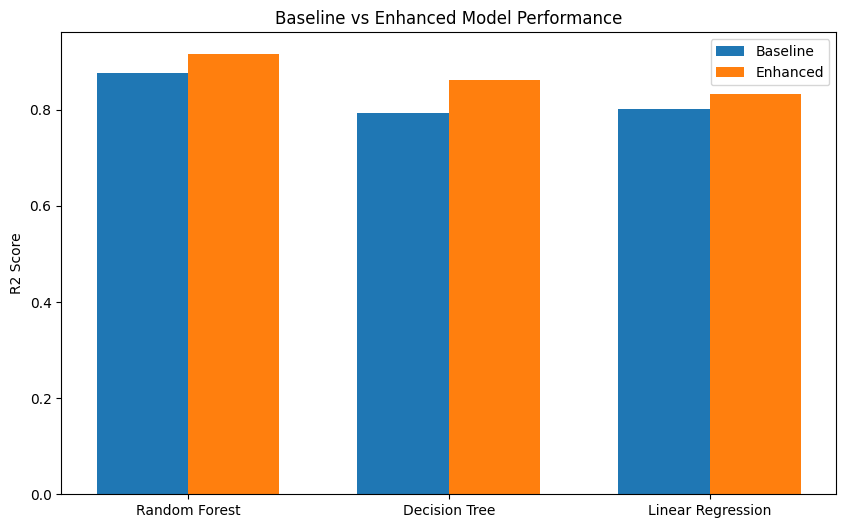

In [10]:
# 그래프 크기
plt.figure(figsize=(10, 6))

# 모델 이름
models_name = results_df["Model"]

# Baseline / Enhanced R2
baseline_r2 = results_df["Baseline R2"]
enhanced_r2 = results_df["Enhanced R2"]

x = np.arange(len(models_name))
width = 0.35

# 막대 그래프
plt.bar(
    x - width/2,
    baseline_r2,
    width,
    label="Baseline"
)

plt.bar(
    x + width/2,
    enhanced_r2,
    width,
    label="Enhanced"
)

# 설정
plt.xticks(x, models_name)

plt.ylabel("R2 Score")

plt.title(
    "Baseline vs Enhanced Model Performance"
)

plt.legend()

plt.show()

## Step 10. 실제 가격 vs 예측 가격 비교

가장 성능이 우수한 모델(Random Forest)을 기준으로 실제 가격과 예측 가격을 비교한다.

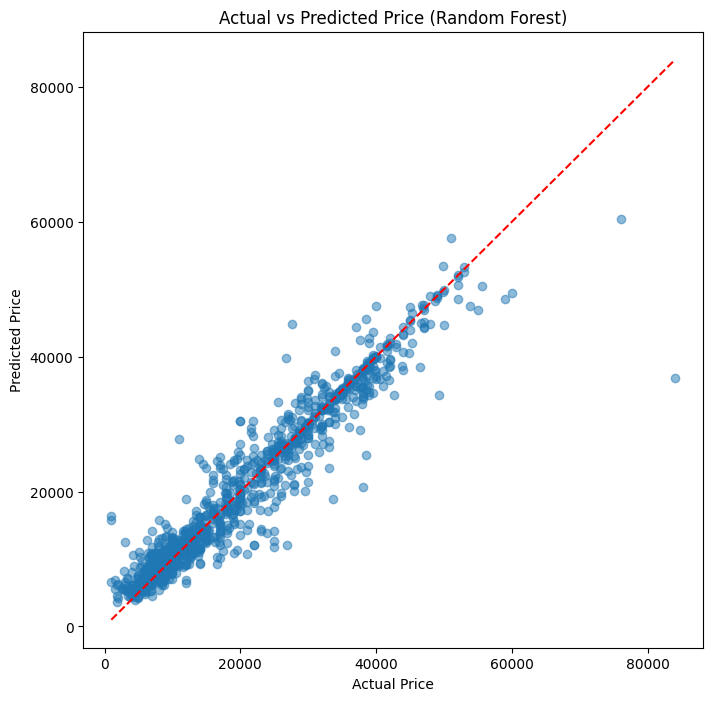

In [11]:
# 최고 성능 모델 선택
best_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# 학습
best_model.fit(
    X_train_enh,
    y_train
)

# 예측
pred_best = best_model.predict(
    X_test_enh
)

# 산점도
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    pred_best,
    alpha=0.5
)

# 기준선
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Price (Random Forest)"
)

plt.show()

# 최종 결론

본 프로젝트에서는 MSRP(feature)가 중고차 가격 예측 성능 향상에 미치는 영향을 분석하였다.

실험 결과, 모든 회귀 모델에서 MSRP feature를 추가한 Enhanced Model이 기존 Baseline Model보다 더 높은 성능을 보였다.

특히 Random Forest Regressor가 가장 우수한 성능을 기록하였다.

- Enhanced R²: 약 0.89
- Enhanced RMSE: 약 4379

이를 통해 MSRP 정보가 실제 중고차 가격 예측에 유의미한 영향을 준다는 것을 확인할 수 있었다.

또한 MSRP 기반 가격 예측 결과는 이후 차량 가격 적정성 분류(Classification)에도 활용 가능하다.

In [12]:
# Best model: Random Forest Enhanced
final_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_enh, y)

df["predicted_price"] = final_model.predict(X_enh)

df["gap_ratio"] = (
    df["price"] - df["predicted_price"]
) / df["predicted_price"]

def classify_price(gap):
    if gap < -0.10:
        return 0   # underpriced
    elif gap > 0.10:
        return 2   # overpriced
    else:
        return 1   # fairly_priced

df["price_class"] = df["gap_ratio"].apply(classify_price)

df.to_csv(
    "vehicles_with_price_class.csv",
    index=False
)

print("저장 완료")

df[["price", "predicted_price", "gap_ratio", "price_class"]].head()

저장 완료


,price,predicted_price,gap_ratio,price_class
0,17995,19649.39,-0.084195,1
1,14995,14401.38,0.041220,1
2,12000,11653.57,0.029727,1
3,13980,12631.25,0.106779,2
4,32590,32968.45,-0.011479,1
